<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_06_Professor_Fundamentos_Visao_Computacional_OpenCV_REVISADO_Resposta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 6 – Fundamentos de Visão Computacional com OpenCV

## Versão do Professor

### Capacidades
- Aplicar visão computacional.
- Demonstrar atenção a detalhes na interpretação de imagens digitais.

### Conhecimentos
- Conceito de visão computacional.
- Representação digital de imagens.
- Pixels e canais RGB.
- Uso básico do OpenCV.
- Conversão RGB/BGR.
- Tons de cinza.
- Redimensionamento.
- Histogramas.
- Filtros.
- Detecção de bordas.
- Limiarização.
- Classificação de imagens.

### Estratégia
Aula expositiva dialogada com demonstração prática em Google Colab, utilizando o dataset CIFAR-10 e a biblioteca OpenCV para contextualizar características de imagens digitais e operações iniciais de visão computacional.

# 1. Contextualização

A visão computacional permite que sistemas computacionais interpretem imagens e vídeos.

Na indústria, pode ser aplicada em inspeção visual, controle de qualidade, detecção de defeitos, leitura de etiquetas, identificação de objetos e monitoramento de processos.

Nesta aula, será utilizado o dataset **CIFAR-10**, disponível no TensorFlow/Keras, e a biblioteca **OpenCV**, muito usada em aplicações práticas de visão computacional.

O objetivo principal é compreender como uma imagem é representada numericamente e como o OpenCV pode auxiliar no pré-processamento visual.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

from tensorflow.keras.datasets import cifar10

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)

TensorFlow: 2.20.0
OpenCV: 4.13.0


# 2. Carregamento do dataset CIFAR-10

O CIFAR-10 possui imagens coloridas de 32x32 pixels distribuídas em 10 classes:

- avião
- automóvel
- pássaro
- gato
- cervo
- cachorro
- sapo
- cavalo
- navio
- caminhão

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

classes = [
    "avião", "automóvel", "pássaro", "gato", "cervo",
    "cachorro", "sapo", "cavalo", "navio", "caminhão"
]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 154s 1us/step
x_train: (50000, 32, 32, 3)
y_train: (50000, 1)
x_test: (10000, 32, 32, 3)
y_test: (10000, 1)


# 3. Análise inicial de uma imagem

Uma imagem colorida é representada como uma matriz tridimensional:

```text
altura x largura x canais
```

No CIFAR-10:

```text
32 x 32 x 3
```

Os 3 canais representam as componentes de cor RGB.

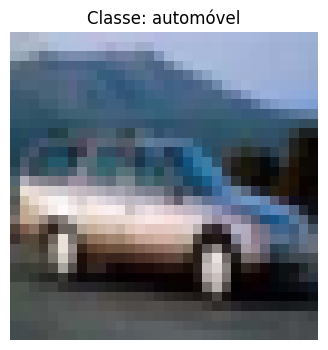

Formato: (32, 32, 3)
Tipo de dado: uint8
Valor mínimo: 0
Valor máximo: 254
Exemplo de pixel [0,0]: [170 180 198]


In [3]:
indice = 4
imagem_rgb = x_train[indice]
classe = int(y_train[indice][0])

plt.figure(figsize=(4,4))
plt.imshow(imagem_rgb)
plt.title(f"Classe: {classes[classe]}")
plt.axis("off")
plt.show()

print("Formato:", imagem_rgb.shape)
print("Tipo de dado:", imagem_rgb.dtype)
print("Valor mínimo:", imagem_rgb.min())
print("Valor máximo:", imagem_rgb.max())
print("Exemplo de pixel [0,0]:", imagem_rgb[0,0])

# 4. OpenCV: diferença entre RGB e BGR

Um ponto essencial:

- O Matplotlib exibe imagens no padrão **RGB**.
- O OpenCV trabalha tradicionalmente com o padrão **BGR**.

Quando a ordem dos canais é interpretada incorretamente, as cores podem aparecer trocadas. Em aplicações industriais, isso pode prejudicar análises de cor, manchas, oxidação e variação de tonalidade.

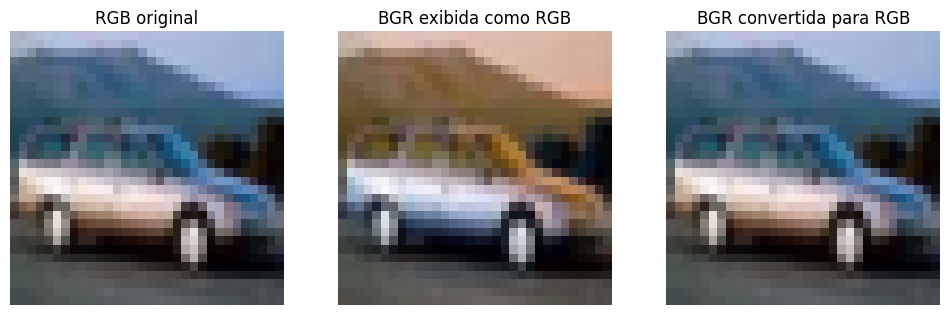

In [4]:
imagem_bgr = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2BGR)
imagem_corrigida = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(imagem_rgb)
plt.title("RGB original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(imagem_bgr)
plt.title("BGR exibida como RGB")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(imagem_corrigida)
plt.title("BGR convertida para RGB")
plt.axis("off")

plt.show()

# 5. Separação dos canais RGB

Separar canais permite analisar a contribuição de cada cor na imagem.

Na indústria, isso pode apoiar inspeções relacionadas a:

- manchas;
- oxidação;
- falhas de pintura;
- sujeira;
- diferença de material;
- variação de tonalidade.

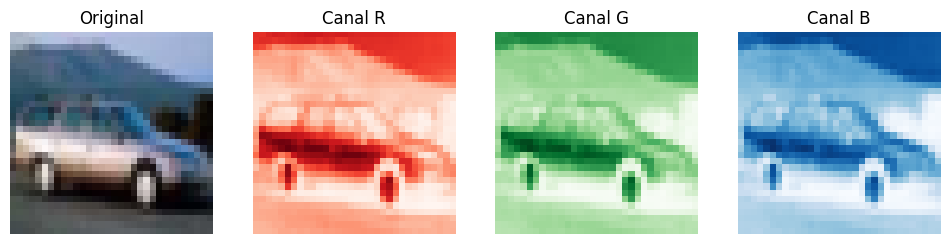

In [5]:
canal_r = imagem_rgb[:, :, 0]
canal_g = imagem_rgb[:, :, 1]
canal_b = imagem_rgb[:, :, 2]

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(imagem_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(canal_r, cmap="Reds")
plt.title("Canal R")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(canal_g, cmap="Greens")
plt.title("Canal G")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(canal_b, cmap="Blues")
plt.title("Canal B")
plt.axis("off")

plt.show()

# 6. Conversão para tons de cinza

A conversão para tons de cinza reduz a imagem de três canais para apenas uma matriz de intensidade.

Formato antes:

```text
32 x 32 x 3
```

Formato depois:

```text
32 x 32
```

Essa conversão é útil quando o foco está em forma, contraste, contorno ou textura, e não na cor.

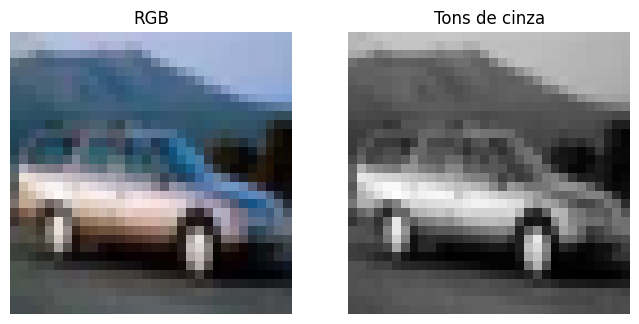

Formato RGB: (32, 32, 3)
Formato cinza: (32, 32)


In [6]:
imagem_gray = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(imagem_rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagem_gray, cmap="gray")
plt.title("Tons de cinza")
plt.axis("off")

plt.show()

print("Formato RGB:", imagem_rgb.shape)
print("Formato cinza:", imagem_gray.shape)

# 7. Redimensionamento

Muitos modelos de visão computacional exigem imagens com tamanho fixo, como 64x64, 128x128 ou 224x224.

O redimensionamento deve ser feito com cuidado, pois pode provocar perda de detalhes ou distorções.

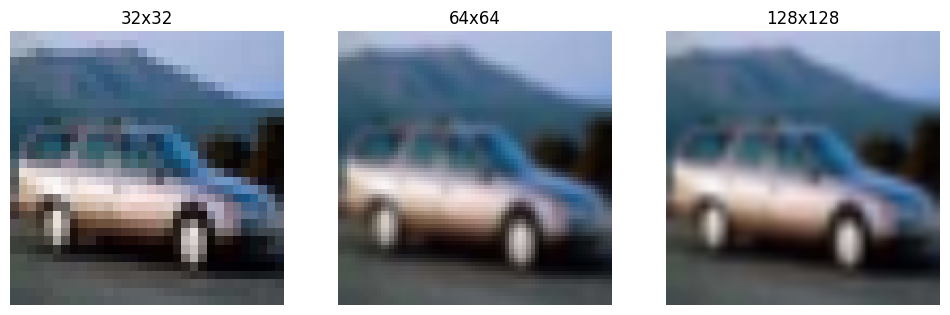

In [7]:
imagem_64 = cv2.resize(imagem_rgb, (64, 64), interpolation=cv2.INTER_LINEAR)
imagem_128 = cv2.resize(imagem_rgb, (128, 128), interpolation=cv2.INTER_LINEAR)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(imagem_rgb)
plt.title("32x32")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(imagem_64)
plt.title("64x64")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(imagem_128)
plt.title("128x128")
plt.axis("off")

plt.show()

# 8. Histogramas

O histograma mostra a distribuição dos valores de intensidade dos pixels.

Ele permite observar brilho, contraste e predominância de cores.

Em inspeção industrial, histogramas podem ajudar a identificar variações visuais entre peças boas e peças com defeito.

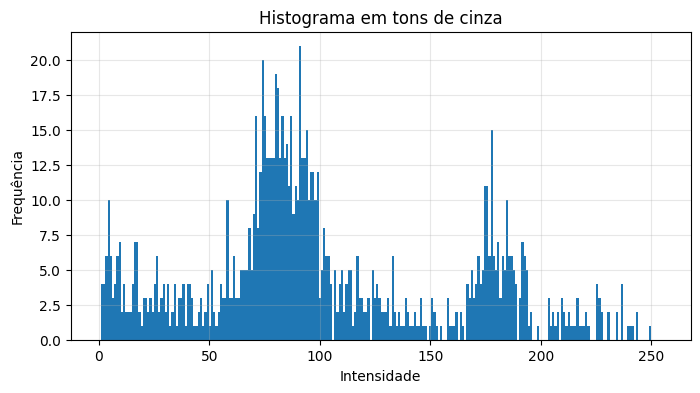

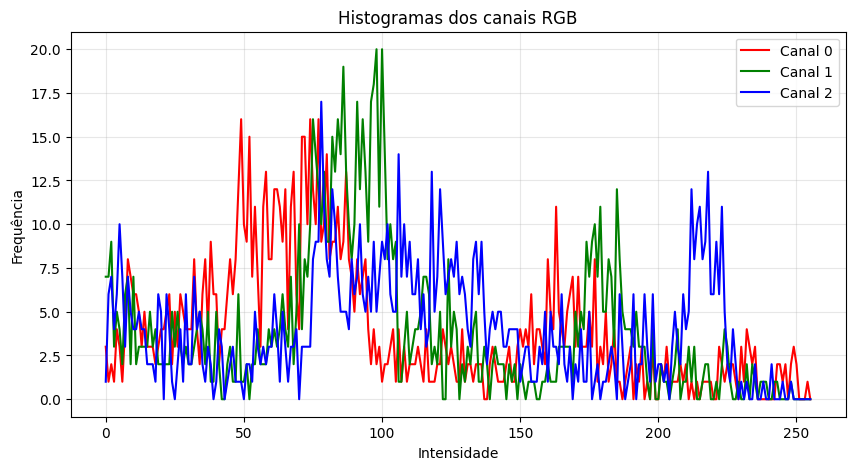

In [8]:
plt.figure(figsize=(8,4))
plt.hist(imagem_gray.ravel(), bins=256, range=(0,255))
plt.title("Histograma em tons de cinza")
plt.xlabel("Intensidade")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,5))
for i, cor in enumerate(["red", "green", "blue"]):
    hist = cv2.calcHist([imagem_rgb], [i], None, [256], [0,256])
    plt.plot(hist, color=cor, label=f"Canal {i}")
plt.title("Histogramas dos canais RGB")
plt.xlabel("Intensidade")
plt.ylabel("Frequência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 9. Filtros: suavização com Gaussian Blur

Filtros alteram a imagem para destacar ou reduzir determinadas características.

O **Gaussian Blur** suaviza a imagem e pode reduzir ruídos.

Em visão computacional, filtros podem ser usados antes de etapas como detecção de bordas ou segmentação.

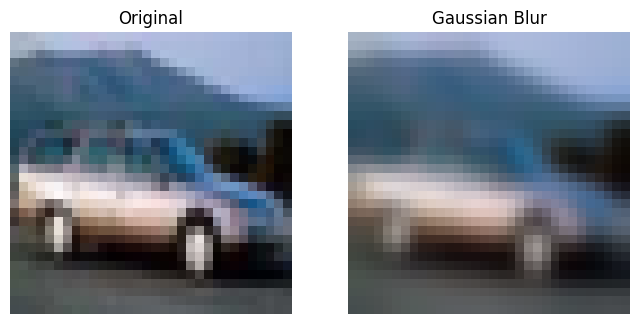

In [9]:
imagem_blur = cv2.GaussianBlur(imagem_rgb, (5,5), 0)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(imagem_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagem_blur)
plt.title("Gaussian Blur")
plt.axis("off")

plt.show()

# 10. Detecção de bordas com Canny

A detecção de bordas identifica regiões com mudanças bruscas de intensidade.

Isso pode ajudar na identificação de contornos, trincas, limites de peças e regiões de interesse.

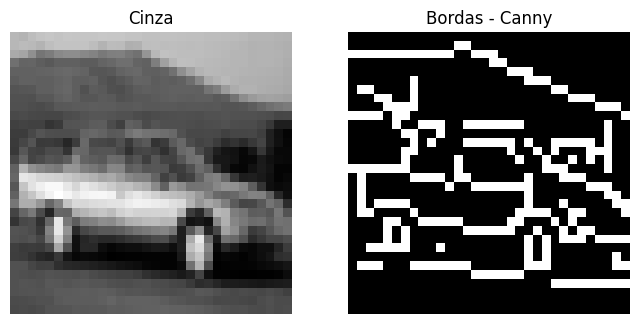

In [10]:
bordas = cv2.Canny(imagem_gray, threshold1=50, threshold2=150)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(imagem_gray, cmap="gray")
plt.title("Cinza")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(bordas, cmap="gray")
plt.title("Bordas - Canny")
plt.axis("off")

plt.show()

# 11. Limiarização

A limiarização transforma uma imagem em tons de cinza em uma imagem binária.

Pixels acima do limiar recebem valor 255.  
Pixels abaixo do limiar recebem valor 0.

Essa técnica é útil quando há contraste claro entre objeto e fundo.

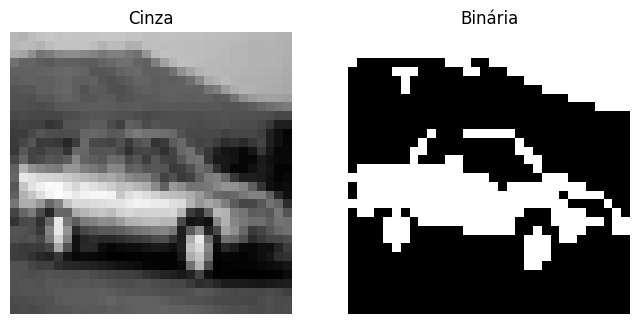

In [11]:
limiar = 100
_, imagem_binaria = cv2.threshold(imagem_gray, limiar, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(imagem_gray, cmap="gray")
plt.title("Cinza")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagem_binaria, cmap="gray")
plt.title("Binária")
plt.axis("off")

plt.show()

# 12. Visualização geral do dataset

Antes de treinar modelos, é importante visualizar amostras do dataset para identificar qualidade, variações, ruídos e dificuldade visual.

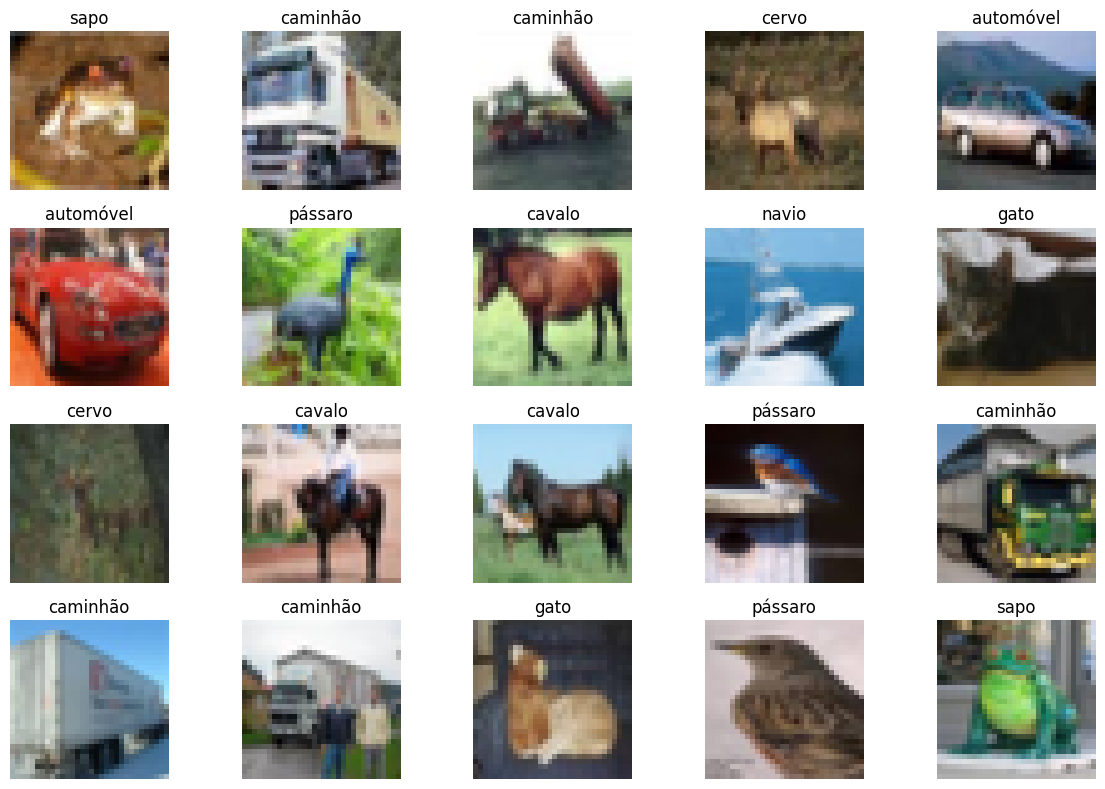

In [12]:
plt.figure(figsize=(12,8))

for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(x_train[i])
    plt.title(classes[int(y_train[i][0])])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 13. Distribuição das classes

Um dataset balanceado possui quantidade semelhante de exemplos em cada classe.

Isso evita que o modelo aprenda de forma enviesada.

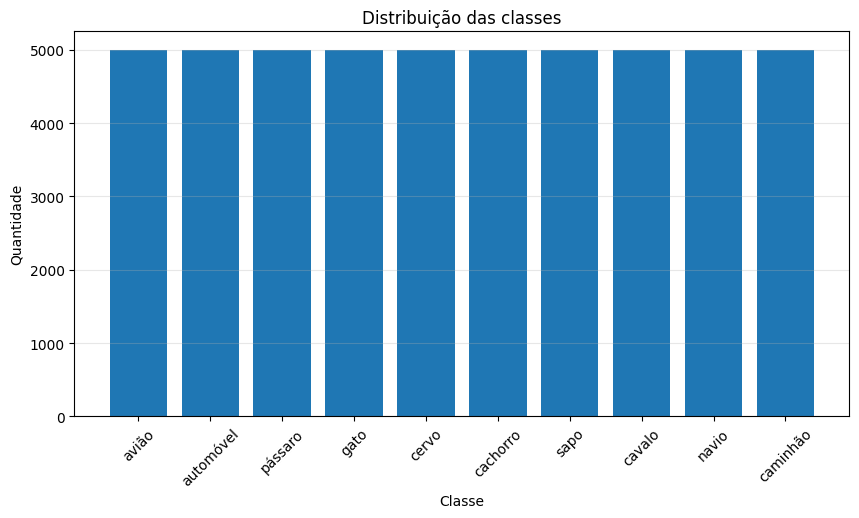

In [13]:
valores, contagens = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,5))
plt.bar([classes[int(v)] for v in valores], contagens)
plt.xticks(rotation=45)
plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 14. Normalização e treinamento simples

A normalização coloca os pixels na escala de 0 a 1, facilitando o treinamento de redes neurais.

Nesta aula, será treinada uma rede densa simples apenas para contextualizar a classificação de imagens.

Na próxima aula, o foco será em CNN, uma arquitetura mais adequada para imagens.

In [14]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

x_train_small = x_train_norm[:5000]
y_train_small = y_train[:5000]
x_test_small = x_test_norm[:1000]
y_test_small = y_test[:1000]

modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
historico = modelo.fit(
    x_train_small,
    y_train_small,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.2007 - loss: 2.1619 - val_accuracy: 0.2490 - val_loss: 2.0175
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.2898 - loss: 1.9590 - val_accuracy: 0.2640 - val_loss: 1.9557
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3178 - loss: 1.8928 - val_accuracy: 0.2840 - val_loss: 1.9285
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3140 - loss: 1.8599 - val_accuracy: 0.3430 - val_loss: 1.8918
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3455 - loss: 1.8071 - val_accuracy: 0.3350 - val_loss: 1.8369
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3537 - loss: 1.7691 - val_accuracy: 0.3560 - val_loss: 1.8050
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3670 - loss: 1.7430 - val_accuracy: 0.3510 - val_loss: 1.8363
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3753 - loss: 1.7294 - val_accuracy: 0.3540 - v

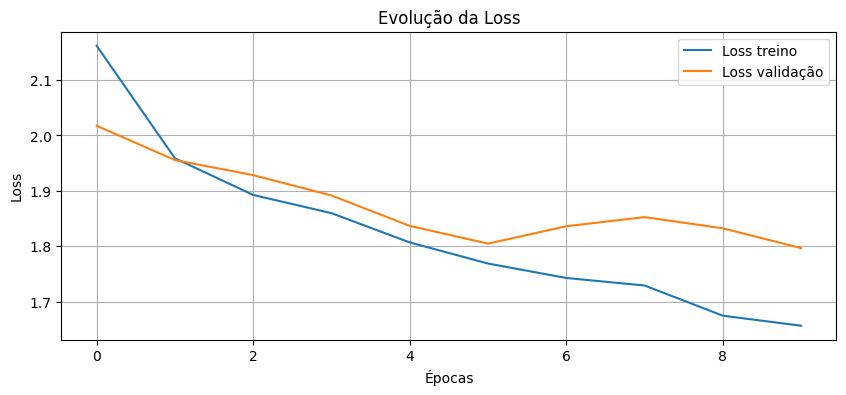

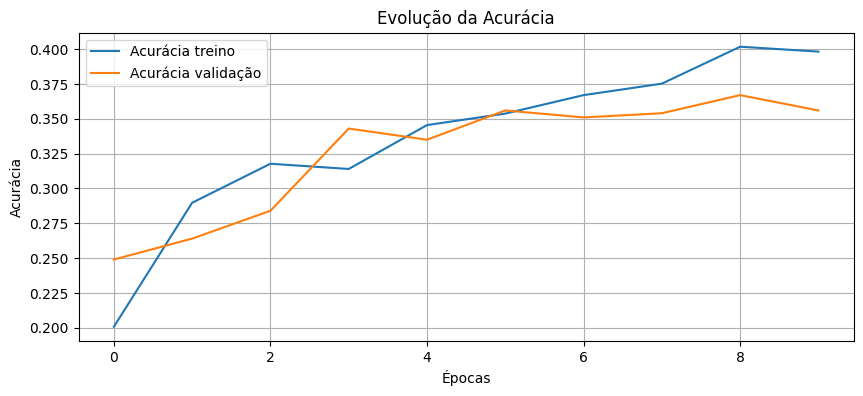

In [16]:
plt.figure(figsize=(10,4))
plt.plot(historico.history["loss"], label="Loss treino")
plt.plot(historico.history["val_loss"], label="Loss validação")
plt.title("Evolução da Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(historico.history["accuracy"], label="Acurácia treino")
plt.plot(historico.history["val_accuracy"], label="Acurácia validação")
plt.title("Evolução da Acurácia")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.show()

# 15. Atividade avaliativa

Responda tecnicamente:

1. O que é um pixel?
Um pixel (picture element) é a menor unidade de uma imagem digital.
Cada pixel representa um ponto na imagem e possui um valor de cor.
Esses valores geralmente são definidos por combinações de cores, como RGB (vermelho, verde e azul).
A qualidade de uma imagem depende da quantidade de pixels (resolução).

2. O que são canais RGB?

Os canais RGB representam as três cores básicas usadas na formação de imagens digitais:

R (Red / Vermelho)
G (Green / Verde)
B (Blue / Azul)

Cada pixel possui três valores, um para cada canal, que indicam a intensidade dessas cores.
A combinação desses valores forma a cor final do pixel.
Por exemplo:

(255, 0, 0) → vermelho puro
(0, 255, 0) → verde puro
(0, 0, 255) → azul puro
(255, 255, 255) → branco

3. Qual é a diferença entre RGB e BGR?

A diferença entre RGB e BGR está na ordem dos canais de cor usados para representar uma imagem.

RGB (Red, Green, Blue): a ordem dos canais é vermelho, verde e azul
BGR (Blue, Green, Red): a ordem dos canais é azul, verde e vermelho

Ambos utilizam os mesmos valores, mas organizados em sequência diferente.
Essa diferença é relevante em bibliotecas como o OpenCV, que usa o padrão BGR por padrão.

4. Por que é importante converter corretamente imagens usadas com OpenCV?

A conversão correta de imagens no OpenCV é importante porque a biblioteca utiliza o padrão BGR, enquanto a maioria dos outros sistemas usa RGB.
Se a conversão não for feita, as cores da imagem serão exibidas incorretamente.
Por exemplo, o que deveria ser vermelho pode aparecer azul.
Isso pode comprometer a interpretação visual e também o desempenho de algoritmos.
Principalmente em tarefas como visão computacional e aprendizado de máquina.

5. Para que serve converter uma imagem para tons de cinza?

Converter uma imagem para tons de cinza serve para simplificar a informação visual, reduzindo a complexidade dos dados.
Em vez de três canais (RGB), a imagem passa a ter apenas um canal de intensidade.
Isso diminui o custo computacional e facilita o processamento.
Também ajuda a destacar padrões, formas e contrastes sem interferência de cores.
É muito utilizado em tarefas como detecção de bordas, reconhecimento de objetos e visão computacional.

6. Para que serve redimensionar imagens?

Redimensionar imagens serve para ajustar suas dimensões (largura e altura) de acordo com a necessidade da aplicação.
Isso é importante para padronizar o tamanho das imagens, especialmente em modelos de visão computacional.
Também ajuda a reduzir o custo computacional, tornando o processamento mais rápido.
Além disso, permite adaptar imagens para diferentes dispositivos ou requisitos de entrada de algoritmos.

7. O que um histograma permite analisar?

Um histograma permite analisar a distribuição dos níveis de intensidade de uma imagem.
Ele mostra quantos pixels existem para cada nível de brilho (de escuro a claro).
Em imagens coloridas, pode representar a distribuição em cada canal (R, G, B).
Ajuda a identificar se a imagem está muito escura, clara ou com bom contraste.

8. Para que serve o Gaussian Blur?

O Gaussian Blur é utilizado para suavizar a imagem, reduzindo ruídos e variações bruscas de intensidade.
Ele aplica um filtro baseado na distribuição gaussiana, criando um efeito de desfoque controlado.
Isso ajuda a eliminar detalhes indesejados e pequenas imperfeições.
Também é muito usado como etapa prévia em operações como detecção de bordas e segmentação.
Além disso, reduz o impacto de ruídos em algoritmos de visão computacional.

9. Para que serve a detecção de bordas?

A detecção de bordas serve para identificar transições bruscas de intensidade em uma imagem, que geralmente correspondem aos contornos dos objetos.
Ela destaca regiões onde há mudança significativa de cor ou brilho.
Isso facilita a identificação de formas, limites e estruturas presentes na imagem.
É amplamente utilizada em tarefas como reconhecimento de objetos e segmentação.
Também ajuda a reduzir a quantidade de dados mantendo apenas informações relevantes.

10. O que é limiarização?

A limiarização (thresholding) é uma técnica de processamento de imagens utilizada para separar objetos do fundo com base na intensidade dos pixels.
Ela converte uma imagem em tons de cinza para uma imagem binária (preto e branco).
Pixels acima de um determinado valor (limiar) recebem um valor (ex: branco).
Pixels abaixo desse valor recebem outro (ex: preto).
Isso facilita a identificação de regiões de interesse.
É muito usada em segmentação de imagens e visão computacional.

11. Cite uma aplicação industrial possível para OpenCV e visão computacional.

Uma aplicação industrial comum de OpenCV e visão computacional é a inspeção automática de qualidade em linhas de produção.
O sistema utiliza câmeras para capturar imagens dos produtos e algoritmos para identificar defeitos, falhas ou não conformidades.
Isso permite detectar problemas como trincas, desalinhamentos ou peças fora do padrão.
A análise é realizada em tempo real, reduzindo erros humanos e aumentando a produtividade.

## Critérios de avaliação

O aluno será avaliado se:

- identifica corretamente características de imagens digitais;
- interpreta pixels, canais e dimensões;
- aplica corretamente operações básicas com OpenCV;
- diferencia RGB e BGR;
- interpreta histogramas, filtros e bordas;
- relaciona os conceitos com aplicações industriais.